<a href="https://colab.research.google.com/github/Balamurugan-T326/Machine-Learning/blob/main/Experiment-8/sc01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   antecedents          consequents   support  confidence      lift
0  (UHT-milk,)  (other vegetables,)  0.038994    0.496732  1.318979
1  (UHT-milk,)        (rolls/buns,)  0.031042    0.395425  1.130863
2  (UHT-milk,)              (soda,)  0.027450    0.349673  1.115406
3  (UHT-milk,)        (whole milk,)  0.040534    0.516340  1.126928
4      (beef,)  (other vegetables,)  0.050795    0.424893  1.128223


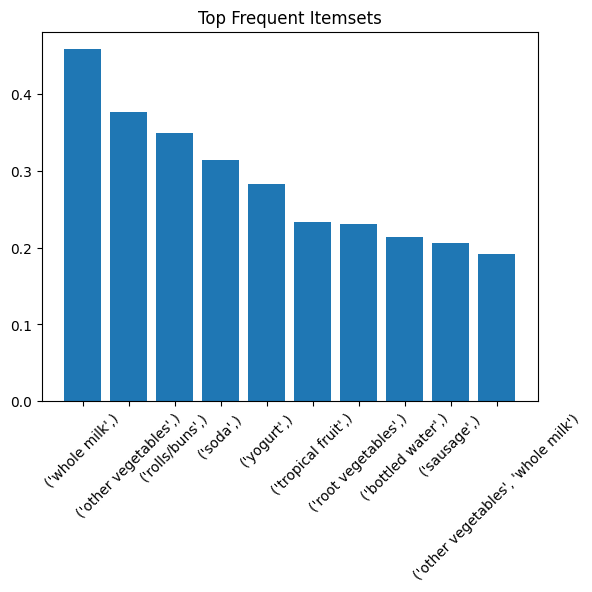

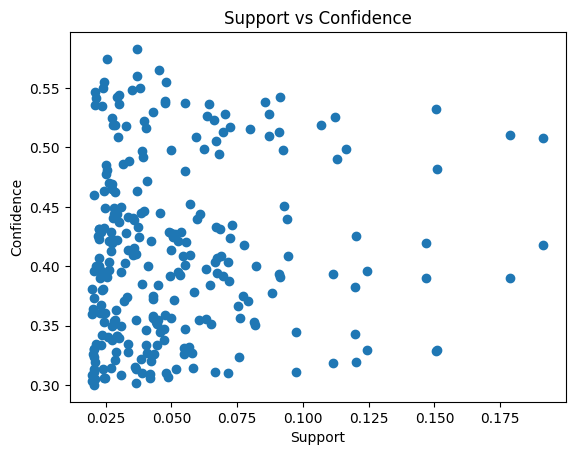

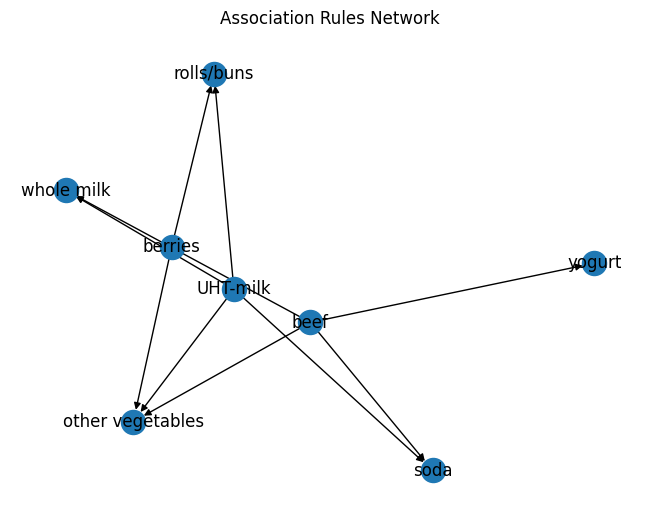

586
267


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from collections import Counter
import networkx as nx
data = pd.read_csv("/content/Groceries_dataset.csv")
transactions = data.groupby('Member_number')['itemDescription'].apply(list).tolist()
total_transactions = len(transactions)
def get_support(itemset):
    count = 0
    for t in transactions:
        if set(itemset).issubset(set(t)):
            count += 1
    return count / total_transactions
items = sorted(set(item for t in transactions for item in t))
min_support = 0.02
frequent_itemsets = {}
for i in range(1, 3):
    for combo in itertools.combinations(items, i):
        sup = get_support(combo)
        if sup >= min_support:
            frequent_itemsets[combo] = sup
rules = []
for itemset in frequent_itemsets:
    if len(itemset) > 1:
        for i in range(1, len(itemset)):
            for antecedent in itertools.combinations(itemset, i):
                consequent = tuple(set(itemset) - set(antecedent))
                sup_itemset = frequent_itemsets[itemset]
                sup_ante = frequent_itemsets.get(antecedent, get_support(antecedent))
                sup_cons = frequent_itemsets.get(consequent, get_support(consequent))
                confidence = sup_itemset / sup_ante
                lift = confidence / sup_cons
                if confidence >= 0.3 and lift > 1:
                    rules.append((antecedent, consequent, sup_itemset, confidence, lift))
rules_df = pd.DataFrame(rules, columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])
print(rules_df.head())
top_items = sorted(frequent_itemsets.items(), key=lambda x: x[1], reverse=True)[:10]
plt.figure()
plt.bar(range(len(top_items)), [x[1] for x in top_items])
plt.xticks(range(len(top_items)), [str(x[0]) for x in top_items], rotation=45)
plt.title("Top Frequent Itemsets")
plt.show()
plt.figure()
plt.scatter(rules_df['support'], rules_df['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()
G = nx.DiGraph()
for _, row in rules_df.head(10).iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c)
plt.figure()
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
plt.title("Association Rules Network")
plt.show()
print(len(frequent_itemsets))
print(len(rules_df))